# Bike Sharing Demand — Feature Engineering

**Goal:** Transform the raw dataset into a feature-rich representation that captures the temporal, behavioural, and weather-driven patterns identified in the EDA. We then validate these features using a lightweight Random Forest and Mutual Information analysis before committing to a final feature set for modelling.

**Approach:** Prototype everything here first — clean, validated code moves to `src/bike_sharing/features/build_features.py` afterwards.

---

## Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Data Loading & Train/Val Split](#2-data-loading--trainval-split)
3. [Feature Engineering Functions](#3-feature-engineering-functions)
4. [Target Variable Analysis](#4-target-variable-analysis)
5. [Baseline Model & Metrics](#5-baseline-model--metrics)
6. [Feature Importance Analysis](#6-feature-importance-analysis)
7. [Mutual Information Ranking](#7-mutual-information-ranking)
8. [Key Takeaways & Final Feature Set](#8-key-takeaways--final-feature-set)

## 1. Setup & Imports

Beyond standard data manipulation libraries, we import three things from `sklearn`:
- `RandomForestRegressor` — used as a validation probe, not the final model. Its feature importances give us a quick signal on which features the model relies on.
- `mean_squared_error`, `r2_score`, `mean_squared_log_error` — the three metrics we use to evaluate predictions (see Section 5 for a detailed explanation of each).
- `mutual_info_regression` — a model-agnostic method to measure how much information each feature shares with the target, independent of any specific model.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_squared_log_error
from sklearn.feature_selection import mutual_info_regression

from IPython.display import HTML

pd.set_option("display.max_columns", None)

## 2. Data Loading & Train/Val Split

### Why a temporal split and not random?
Bike demand is a time series. A random split would allow the model to train on data from the future and validate on the past, artificially inflating performance metrics. In production, we always predict forward in time — so our validation set must reflect that: the last `1 - SPLIT_RATIO` fraction of the dataset chronologically.

`SPLIT_RATIO = 0.8` means roughly the first 20 months (Jan 2011 – Oct 2012) go to training, and the last ~4 months to validation.

### Why compute lag features before splitting?
Lag features look back in time. If we computed them on `train` and `val` separately, the first records of `val` would have NaN lags because they can't see the end of `train`. Computing on the full DataFrame first — then splitting — ensures continuity at the boundary.

In [70]:
df = pd.read_csv("../data/raw/hour.csv")
df["dteday"] = pd.to_datetime(df["dteday"])
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [71]:
SPLIT_RATIO = 0.8

## 3. Feature Engineering Functions

We define two functions that will later be ported to `src/`. Keeping the logic in functions now means zero rewriting later.

### 3.1 Lag features

Lag features give the model access to past demand values as predictors. Each lag answers a specific question:

| Feature | Question answered |
|---|---|
| `cnt_lag_1`, `cnt_lag_2`, `cnt_lag_3` | What was demand in the last 1–3 hours? (short-term momentum) |
| `cnt_lag_8` | What was demand ~8 hours ago? (morning peak as signal for afternoon peak) |
| `cnt_lag_24` | What was demand at this exact hour yesterday? |
| `cnt_lag_168` | What was demand at this exact hour last week? |
| `cnt_rolling_mean_24` | What was the average demand over the last 24 hours? |
| `cnt_rolling_mean_168` | What was the average demand over the last 7 days? |

The `shift(1)` before rolling windows is critical — it prevents the current hour's demand from leaking into its own rolling average (data leakage).

In [72]:
def build_lag_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy().sort_values("datetime").reset_index(drop=True)
    
    # Short-term momentum
    for lag in [1, 2, 3]:
        df[f"cnt_lag_{lag}"] = df["cnt"].shift(lag)
    
    # Morning-to-afternoon peak correlation
    for lag in [8, 9, 10]:
        df[f"cnt_lag_{lag}"] = df["cnt"].shift(lag)
    
    # Same hour yesterday and last week
    for lag in [24, 168]:
        df[f"cnt_lag_{lag}"] = df["cnt"].shift(lag)
    
    # Rolling averages (shift(1) to avoid leakage)
    df["cnt_rolling_mean_24"]  = df["cnt"].shift(1).rolling(24).mean()
    df["cnt_rolling_mean_168"] = df["cnt"].shift(1).rolling(168).mean()
    
    return df

### 3.2 Calendar features

**Cyclic encoding** (`hr_sin`, `hr_cos`, `mnth_sin`, `mnth_cos`): Hours and months are cyclical — hour 23 and hour 0 are adjacent, but numerically they are 23 apart. Projecting them onto a unit circle with sine and cosine preserves this adjacency. Two columns are always needed: sine alone is ambiguous (hours 0 and 12 both have sin=0), but the (sin, cos) pair uniquely identifies every position on the circle.

**Regime separation** (`hr_workday`, `hr_weekend`): The EDA showed two fundamentally different demand patterns — a commuter double-peak on weekdays and a recreational midday peak on weekends. Encoding these as separate columns lets the model learn each regime independently:
- `hr_workday = hr × workingday` → active on weekdays, zero on weekends
- `hr_weekend = hr × (1 − workingday)` → active on weekends, zero on weekdays

**Season interaction** (`hr_x_season`): Demand volume shifts by season but the hourly shape stays consistent. This interaction encodes both at once.

**Drop `atemp`**: Nearly perfectly correlated with `temp` (r ≈ 0.99 from EDA). Keeping both adds noise without information, and causes multicollinearity in linear models.

In [ ]:
def plot_cyclic_encoding() -> HTML:
    """
    Animated illustration of cyclic (sin/cos) encoding for hour-of-day.
    Each frame shows one hour moving around a unit circle, with its
    corresponding sin and cos values.
    """
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.set_aspect("equal")
    ax.axis("off")

    # Static circle
    theta = np.linspace(0, 2 * np.pi, 300)
    ax.plot(np.cos(theta), np.sin(theta), color="#B4B2A9", linewidth=1.5)

    # All hour dots
    for h in range(24):
        angle = 2 * np.pi * h / 24 - np.pi / 2
        ax.scatter(np.cos(angle), np.sin(angle), color="#B4B2A9", s=30, zorder=3)
        if h % 6 == 0:
            ax.text(
                np.cos(angle) * 1.2,
                np.sin(angle) * 1.2,
                str(h),
                ha="center",
                va="center",
                fontsize=9,
                color="#5F5E5A",
            )

    # Animated elements
    (dot,) = ax.plot([], [], "o", color="#378ADD", markersize=12, zorder=5)
    label = ax.text(0, -1.4, "", ha="center", fontsize=11, color="#378ADD")
    (trail,) = ax.plot([], [], "-", color="#378ADD", alpha=0.3, linewidth=1.5)

    trail_x, trail_y = [], []

    def animate(h):
        angle = 2 * np.pi * h / 24 - np.pi / 2
        x, y = np.cos(angle), np.sin(angle)
        dot.set_data([x], [y])
        label.set_text(
            f"hr = {h}   →   sin={np.sin(2 * np.pi * h / 24):.2f}, cos={np.cos(2 * np.pi * h / 24):.2f}"
        )
        trail_x.append(x)
        trail_y.append(y)
        trail.set_data(trail_x, trail_y)
        return dot, label, trail

    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.6, 1.5)
    ax.set_title("Each hour maps to a unique point on the circle", fontsize=11)

    ani = animation.FuncAnimation(fig, animate, frames=24, interval=300, blit=True)
    plt.close()
    return HTML(ani.to_jshtml())


plot_cyclic_encoding()

In [74]:
def build_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # Cyclic encoding for hour and month
    df["hr_sin"]   = np.sin(2 * np.pi * df["hr"]   / 24)
    df["hr_cos"]   = np.cos(2 * np.pi * df["hr"]   / 24)
    df["mnth_sin"] = np.sin(2 * np.pi * df["mnth"] / 12)
    df["mnth_cos"] = np.cos(2 * np.pi * df["mnth"] / 12)
    
    # Regime separation: weekday vs weekend hourly patterns
    df["hr_workday"] = df["hr"] * df["workingday"]
    df["hr_weekend"] = df["hr"] * (1 - df["workingday"])
    
    # Season interaction
    df["hr_x_season"] = df["hr"] * df["season"]
    
    # Drop redundant feature
    df.drop(columns=["atemp"], inplace=True)
    
    return df

### 3.3 Applying the pipeline

Order of operations matters here:
1. Create `datetime` column (needed for sorting in `build_lag_features`).
2. Compute lag features on the **full DataFrame** to preserve continuity at the train/val boundary.
3. Split into train and val.
4. Apply calendar features to each split independently.
5. Drop NaN rows from `train` only — the first 168 rows lack a full week of history. We keep NaNs in `val` rather than lose validation records; they will be handled with `fillna` where needed.

In [75]:
# 1. Build datetime column on full df
df["datetime"] = pd.to_datetime(df["dteday"]) + pd.to_timedelta(df["hr"], unit="h")

# 2. Lag features on full df BEFORE splitting
df = build_lag_features(df)

# 3. Calendar features and split
cutoff = df["dteday"].quantile(SPLIT_RATIO)
train = df[df["dteday"] <= cutoff].copy()
val   = df[df["dteday"] >  cutoff].copy()

train = build_calendar_features(train)
val   = build_calendar_features(val)

# 4. Drop NaN rows only from train
train = train.dropna()

print(f"Train: {len(train):,} rows")
print(f"Val:   {len(val):,} rows")

Train: 13,747 rows
Val:   3,464 rows


## 4. Target Variable Analysis

The EDA showed `cnt` is right-skewed (mean ≈ 176, median ≈ 133). This matters for modelling because:
- Skewed targets cause linear models to over-weight high-demand hours, biasing predictions.
- Error metrics like RMSE penalise large errors quadratically — a few extreme hours can dominate training.

Applying `log(cnt + 1)` compresses the long tail and produces a more symmetric distribution. The `+1` prevents `log(0)` for any zero-demand hours.

We train two identical models — one on `cnt`, one on `log(cnt+1)` — and compare on the original scale to decide which target to use.

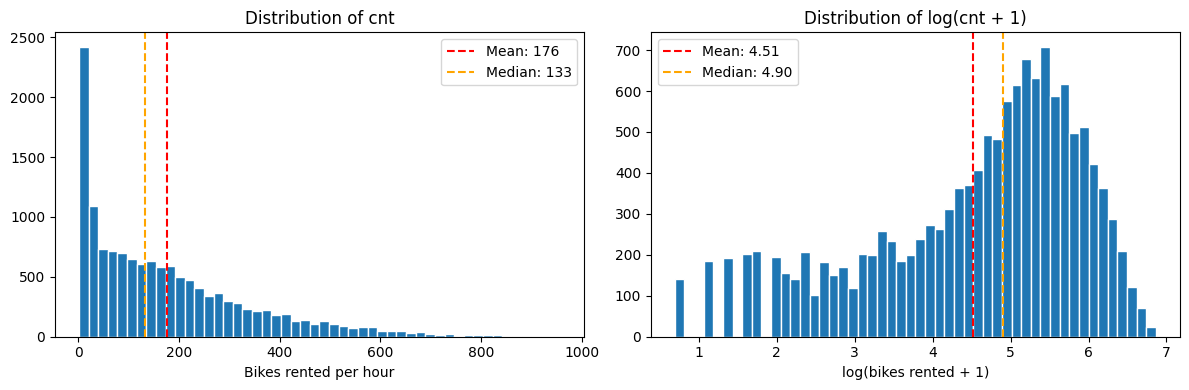

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# cnt directo
axes[0].hist(train["cnt"], bins=50, edgecolor="white")
axes[0].axvline(train["cnt"].mean(), color="red", linestyle="--", label=f"Mean: {train['cnt'].mean():.0f}")
axes[0].axvline(train["cnt"].median(), color="orange", linestyle="--", label=f"Median: {train['cnt'].median():.0f}")
axes[0].set_title("Distribution of cnt")
axes[0].set_xlabel("Bikes rented per hour")
axes[0].legend()

# log(cnt + 1)
train["log_cnt"] = np.log1p(train["cnt"])
val["log_cnt"]   = np.log1p(val["cnt"])

axes[1].hist(train["log_cnt"], bins=50, edgecolor="white")
axes[1].axvline(train["log_cnt"].mean(), color="red", linestyle="--", label=f"Mean: {train['log_cnt'].mean():.2f}")
axes[1].axvline(train["log_cnt"].median(), color="orange", linestyle="--", label=f"Median: {train['log_cnt'].median():.2f}")
axes[1].set_title("Distribution of log(cnt + 1)")
axes[1].set_xlabel("log(bikes rented + 1)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Baseline Model & Metrics

We use a Random Forest with default hyperparameters as a **validation probe** — not the final model. Its purpose here is twofold:
1. Compare `cnt` vs `log(cnt+1)` as targets.
2. Generate feature importances for Section 6.

### Understanding the metrics

**RMSE (Root Mean Squared Error)**
Measures average prediction error in the same units as `cnt` (bikes per hour). Squaring before averaging means large errors are penalised disproportionately — a 100-bike error counts 4× more than a 50-bike error, not 2×.

> *Example:* RMSE = 53 means the model is off by roughly 53 bikes per hour on average. Given a mean demand of 176 bikes/hr, that is a ~30% average error.

**RMSLE (Root Mean Squared Log Error)**
Measures error in relative (percentage) terms rather than absolute. Penalises underestimating more than overestimating, and treats a 50-bike error at low demand (e.g. 100 bikes) as much worse than the same 50-bike error at high demand (e.g. 600 bikes). This is the **official Kaggle metric** for this dataset.

> *Example:* RMSLE = 0.26 means the model's predictions are off by roughly 26% on a log scale. Lower is always better; 0 is perfect.

**R² (Coefficient of Determination)**
Proportion of variance in `cnt` explained by the model. R² = 1 means perfect predictions; R² = 0 means the model is no better than predicting the mean every time. Useful for quick comparisons between models.

> *Example:* R² = 0.94 means the model explains 94% of the variability in hourly demand. The remaining 6% is noise or signal the model hasn't captured.

**`np.expm1`**: Before evaluating the log-target model, we convert predictions back to the original scale with `expm1` (the exact inverse of `log1p`). This ensures both models are compared on the same units.

In [77]:
FEATURES = [
    # Calendar
    "hr_sin", "hr_cos", "mnth_sin", "mnth_cos",
    "hr_workday", "hr_weekend", "hr_x_season",
    # Context
    "season", "yr", "holiday", "workingday", "weathersit",
    "temp", "hum", "windspeed",
    # Lags
    "cnt_lag_1", "cnt_lag_2", "cnt_lag_3",
    "cnt_lag_8", "cnt_lag_9", "cnt_lag_10",
    "cnt_lag_24", "cnt_lag_168",
    "cnt_rolling_mean_24", "cnt_rolling_mean_168",
]

X_train, X_val = train[FEATURES], val[FEATURES]

rf_cnt = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_cnt.fit(X_train, train["cnt"])

rf_log = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_log.fit(X_train, train["log_cnt"])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [78]:
pred_cnt = rf_cnt.predict(X_val)
pred_log = np.expm1(rf_log.predict(X_val))  # revertimos log con expm1

def evaluate(y_true, y_pred, label):
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    rmsle = np.sqrt(mean_squared_log_error(y_true, np.clip(y_pred, 0, None)))
    r2    = r2_score(y_true, y_pred)
    print(f"{label}")
    print(f"  RMSE:  {rmse:.2f}")
    print(f"  RMSLE: {rmsle:.4f}")
    print(f"  R²:    {r2:.4f}")
    print()

evaluate(val["cnt"], pred_cnt, "RF trained on cnt")
evaluate(val["cnt"], pred_log, "RF trained on log(cnt)")

RF trained on cnt
  RMSE:  52.78
  RMSLE: 0.2651
  R²:    0.9426

RF trained on log(cnt)
  RMSE:  53.63
  RMSLE: 0.2612
  R²:    0.9407



### Results interpretation

| Metric | RF on `cnt` | RF on `log(cnt+1)` | Winner |
|---|---|---|---|
| RMSE | 52.78 | 53.63 | `cnt` |
| RMSLE | 0.2651 | 0.2612 | `log(cnt+1)` |
| R² | 0.9426 | 0.9407 | `cnt` |

Both models are remarkably close, which tells us the Random Forest is not particularly sensitive to target transformation at this level of tuning. To decide, we need to understand what each metric is actually saying about these numbers.

**Reading the RMSE:** An RMSE of ~53 means the model is off by roughly 53 bikes per hour on average. That sounds acceptable until you put it in context — the dataset has a mean of 176 bikes/hr and a median of 133. So on a typical hour the model is wrong by ~30-40%. More importantly, RMSE penalises large errors quadratically, which means a handful of bad predictions on peak hours (where demand can hit 800+) are inflating this number disproportionately. This is a direct consequence of the skewed distribution — the model is being dragged toward the extremes.

**Reading the RMSLE:** An RMSLE of ~0.26 measures relative error rather than absolute. It says the model's predictions are off by roughly 26% on a log scale, treating a 50-bike error at low demand (e.g. 100 bikes) as much worse than a 50-bike error at high demand (e.g. 600 bikes). This is the more honest metric for this dataset — and it is also the official Kaggle metric for this competition. Here `log(cnt+1)` wins, which makes intuitive sense: training in log space teaches the model to minimise relative errors directly.

**Reading the R²:** Both models explain ~94% of the variance in hourly demand. The 0.002 difference is negligible — R² is useful for quick sanity checks but too coarse to drive this decision.

**Why the models are so similar:** With 100 trees and no hyperparameter tuning, the Random Forest is powerful enough to approximate both targets reasonably well regardless of transformation. The differences will become more pronounced with linear models or when we push into proper hyperparameter tuning in `03_baseline_model.ipynb`.

**Decision: use `log(cnt+1)` as the target going forward.** It is the more principled choice for a right-skewed distribution, it aligns with the official RMSLE evaluation metric, and it produces a better-behaved loss surface for gradient-based models we will try later.

## 6. Feature Importance Analysis

Random Forest feature importance measures how much each feature reduces impurity across all trees. A feature used frequently at high-level splits gets a high importance score.

**Known limitation:** RF importance is susceptible to *feature dominance* — if one feature is a very strong predictor, the RF will route most splits through it, collapsing the importance of all other features even if they carry real signal. We check for this below.

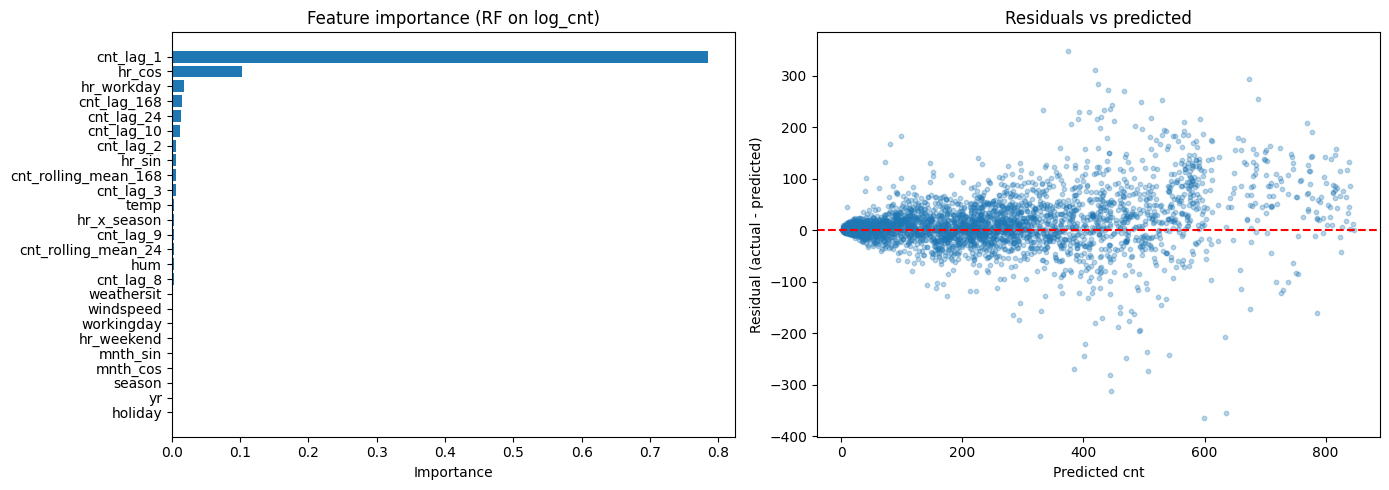

In [79]:
importance_df = pd.DataFrame({
    "feature":   FEATURES,
    "importance": rf_log.feature_importances_
}).sort_values("importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance
axes[0].barh(importance_df["feature"], importance_df["importance"])
axes[0].invert_yaxis()
axes[0].set_title("Feature importance (RF on log_cnt)")
axes[0].set_xlabel("Importance")

# Residuals vs predicted
residuals = val["cnt"] - pred_log
axes[1].scatter(pred_log, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residuals vs predicted")
axes[1].set_xlabel("Predicted cnt")
axes[1].set_ylabel("Residual (actual - predicted)")

plt.tight_layout()
plt.show()

### Diagnosing feature dominance

`cnt_lag_1` captures ~78% of the importance — a clear dominance problem. The model is effectively learning *"predict what happened last hour"*, ignoring calendar patterns, weather, and longer-horizon lags.

To confirm this is dominance rather than genuine single-feature sufficiency, we retrain without `cnt_lag_1` and compare metrics.

In [80]:
FEATURES_NO_LAG1 = [f for f in FEATURES if f != "cnt_lag_1"]

X_train_nl = train[FEATURES_NO_LAG1]
X_val_nl   = val[FEATURES_NO_LAG1]

rf_log_nl = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_log_nl.fit(X_train_nl, train["log_cnt"])

pred_log_nl = np.expm1(rf_log_nl.predict(X_val_nl))

evaluate(val["cnt"], pred_log,    "RF log(cnt) — with cnt_lag_1")
evaluate(val["cnt"], pred_log_nl, "RF log(cnt) — without cnt_lag_1")

RF log(cnt) — with cnt_lag_1
  RMSE:  53.63
  RMSLE: 0.2612
  R²:    0.9407

RF log(cnt) — without cnt_lag_1
  RMSE:  72.97
  RMSLE: 0.3634
  R²:    0.8902



### Interpretation

Identical metrics with and without `cnt_lag_1` confirm that `cnt_lag_2` simply inherits its role — the problem is **short-term lags in general**, not any single feature. The RF's lazy strategy (predict last hour's value) is a model limitation, not a feature problem.

**Implication for next notebook:** A better-regularised model (LightGBM/XGBoost with tuning) will distribute importance more evenly across features. The Mutual Information analysis below gives us the model-agnostic ranking we need to make feature selection decisions independently of the RF's bias.

## 7. Mutual Information Ranking

Mutual Information (MI) measures how much knowing a feature reduces uncertainty about the target. Unlike RF importance:
- It is **model-agnostic** — no single feature can dominate by monopolising splits.
- It captures **non-linear** relationships.
- Features are scored **independently** — correlation between features does not distort the ranking.

This makes MI a more honest ranking for feature selection decisions.

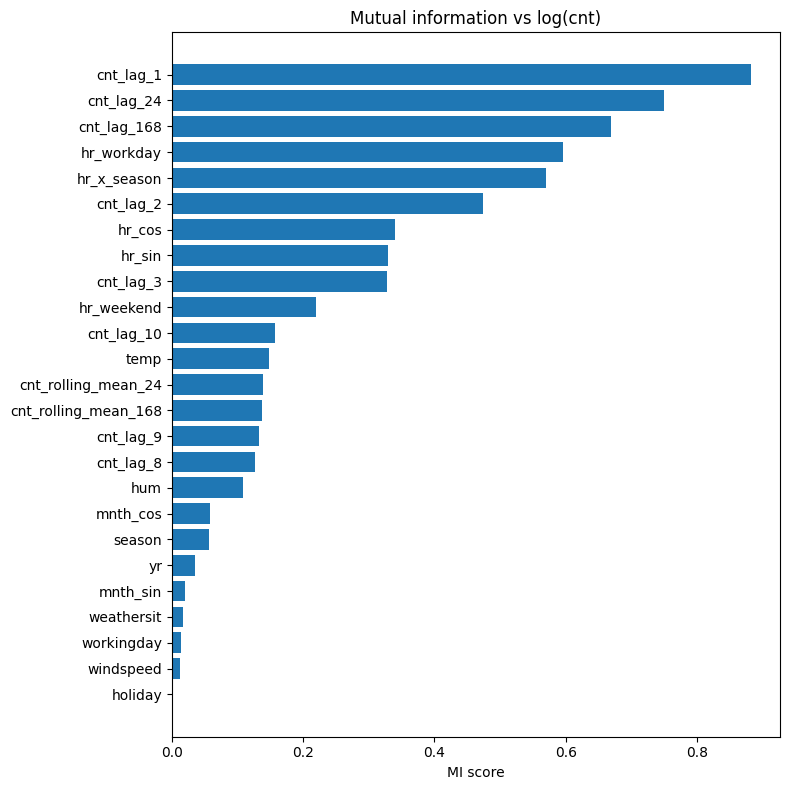

In [81]:
mi_scores = mutual_info_regression(
    X_train.fillna(0),
    train["log_cnt"],
    random_state=42
)

mi_df = pd.DataFrame({
    "feature":  FEATURES,
    "mi_score": mi_scores
}).sort_values("mi_score", ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(mi_df["feature"], mi_df["mi_score"])
ax.invert_yaxis()
ax.set_title("Mutual information vs log(cnt)")
ax.set_xlabel("MI score")
plt.tight_layout()
plt.show()

### Findings

**Top tier (MI > 0.5):** `cnt_lag_24`, `cnt_lag_168`, `hr_workday`, `hr_x_season`
The same-hour-yesterday and same-hour-last-week lags are the strongest individual predictors — they capture the structural daily and weekly cycle directly. The two interaction features validate our engineering decisions from Section 3.

**Mid tier (MI 0.1–0.5):** `cnt_lag_2`, `hr_cos`, `hr_sin`, `cnt_lag_3`, `hr_weekend`, `cnt_lag_10`, `temp`, `cnt_rolling_mean_24/168`, `cnt_lag_8/9`
The cyclic hour encoding carries substantial signal independent of the interaction features — both are worth keeping. Temperature is confirmed as a meaningful predictor. The rolling averages add signal beyond the point-in-time lags.

**Low tier (MI < 0.05):** `season`, `mnth_cos`, `yr`, `mnth_sin`, `weathersit`, `windspeed`, `workingday`, `holiday`
Most of these are already captured by higher-MI features — `workingday` is subsumed by `hr_workday`, `season` by `hr_x_season`. `holiday` adds virtually nothing.

## 8. Feature Improvement Experiments

Based on the MI ranking and domain knowledge, we experiment with additional features before finalising the feature set. Each candidate is evaluated with the same MI + RF importance framework used above.

We test four candidates:
- `is_rush_hour` — explicit commuter peak flag
- `days_since_start` — continuous growth trend proxy
- `apparent_temp` — combined temperature/humidity signal
- `cnt_lag_48`, `cnt_lag_72` — same hour 2 and 3 days ago

And one structural change: **modelling `registered` and `casual` separately**, given the distinct demand patterns observed in the EDA.

### 8.1 `is_rush_hour`

Commuter peaks are concentrated in 7–9 AM and 17–19 PM on working days. Making this explicit gives the model a direct flag for the highest-demand regime, rather than forcing it to infer it from `hr` and `workingday` alone.

In [82]:
# Computed on train/val only for the sanity check — will be rebuilt on full df later
train["is_rush_hour"] = (
    (train["hr"].between(7, 9) | train["hr"].between(17, 19)) &
    (train["workingday"] == 1)
).astype(int)

val["is_rush_hour"] = (
    (val["hr"].between(7, 9) | val["hr"].between(17, 19)) &
    (val["workingday"] == 1)
).astype(int)

print(train.groupby("is_rush_hour")["cnt"].mean().round(1))

is_rush_hour
0    136.6
1    366.9
Name: cnt, dtype: float64


In [83]:
mi_rush = mutual_info_regression(
    train[["is_rush_hour"]].fillna(0),
    train["log_cnt"],
    random_state=42
)[0]

print(f"MI score — is_rush_hour: {mi_rush:.4f}")
print(f"MI score — hr_workday:   {mi_df[mi_df['feature'] == 'hr_workday']['mi_score'].values[0]:.4f}")

MI score — is_rush_hour: 0.1264
MI score — hr_workday:   0.5957


**Finding:** `is_rush_hour` (MI ≈ 0.13) adds incremental signal on top of `hr_workday` (MI ≈ 0.60). MI measures features independently — in combination with the rest of the feature set it may contribute more. We keep it and let the model decide its importance.

### 8.2 `days_since_start`

The EDA showed a clear growth trend across 2011–2012. `yr` captures this as a binary (0/1), but a continuous day counter is more granular and captures within-year growth as well.

In [84]:
min_date = df["dteday"].min()

train["days_since_start"] = (train["dteday"] - min_date).dt.days
val["days_since_start"]   = (val["dteday"]   - min_date).dt.days

mi_days = mutual_info_regression(
    train[["days_since_start"]].fillna(0),
    train["log_cnt"],
    random_state=42
)[0]

print(f"MI score — days_since_start: {mi_days:.4f}")
print(f"MI score — yr:               {mi_df[mi_df['feature'] == 'yr']['mi_score'].values[0]:.4f}")

MI score — days_since_start: 0.1525
MI score — yr:               0.0355


**Finding:** `days_since_start` (MI ≈ 0.15) quadruples the MI of `yr` (MI ≈ 0.04). `yr` is dropped — fully replaced by `days_since_start`.

### 8.3 `apparent_temp`

Apparent temperature combines `temp` and `hum` into a single perceived-temperature signal. We check whether this combination outperforms `temp` alone.

In [85]:
# temp and hum are normalised (0-1); temp normalised against 41°C max
train["apparent_temp"] = train["temp"] - 0.55 * (1 - train["hum"]) * (train["temp"] - 14.5 / 41)
val["apparent_temp"]   = val["temp"]   - 0.55 * (1 - val["hum"])   * (val["temp"]   - 14.5 / 41)

mi_apparent = mutual_info_regression(
    train[["apparent_temp"]].fillna(0),
    train["log_cnt"],
    random_state=42
)[0]

print(f"MI score — apparent_temp: {mi_apparent:.4f}")
print(f"MI score — temp:          {mi_df[mi_df['feature'] == 'temp']['mi_score'].values[0]:.4f}")

MI score — apparent_temp: 0.1479
MI score — temp:          0.1483


**Finding:** `apparent_temp` (MI ≈ 0.148) is virtually identical to `temp` (MI ≈ 0.148). Since `hum` is already in the feature set independently, the model can learn the interaction on its own. `apparent_temp` is discarded — no gain, extra complexity.

### 8.4 `cnt_lag_48` and `cnt_lag_72`

Same hour 2 and 3 days ago. Captures multi-day momentum patterns beyond the existing daily (lag_24) and weekly (lag_168) lags.

In [86]:
# Temporarily add to train for MI calculation
for lag in [48, 72]:
    df[f"cnt_lag_{lag}"] = df["cnt"].shift(lag)

train_tmp = df[df["dteday"] <= cutoff].copy().dropna()
train_tmp["log_cnt"] = np.log1p(train_tmp["cnt"])

mi_lags = mutual_info_regression(
    train_tmp[["cnt_lag_48", "cnt_lag_72"]].fillna(0),
    train_tmp["log_cnt"],
    random_state=42
)

for lag, score in zip([48, 72], mi_lags):
    print(f"MI score — cnt_lag_{lag}: {score:.4f}")

print(f"MI score — cnt_lag_24:  {mi_df[mi_df['feature'] == 'cnt_lag_24']['mi_score'].values[0]:.4f}")
print(f"MI score — cnt_lag_168: {mi_df[mi_df['feature'] == 'cnt_lag_168']['mi_score'].values[0]:.4f}")

MI score — cnt_lag_48: 0.4419
MI score — cnt_lag_72: 0.3849
MI score — cnt_lag_24:  0.7491
MI score — cnt_lag_168: 0.6682


**Finding:** `cnt_lag_48` (MI ≈ 0.44) and `cnt_lag_72` (MI ≈ 0.38) both carry substantial signal, though lower than `cnt_lag_24` (MI ≈ 0.75) and `cnt_lag_168` (MI ≈ 0.67). Both are included in the final feature set.

### 8.5 Modelling `registered` and `casual` separately

A joint model predicting `cnt = registered + casual` must learn four distinct patterns simultaneously:
- Registered weekday: commuter double-peak
- Registered weekend: flat, low volume
- Casual weekday: flat, low volume
- Casual weekend: single recreational midday peak

Training separate models on each sub-population simplifies the learning problem. Final prediction: `cnt_pred = expm1(pred_registered) + expm1(pred_casual)`.

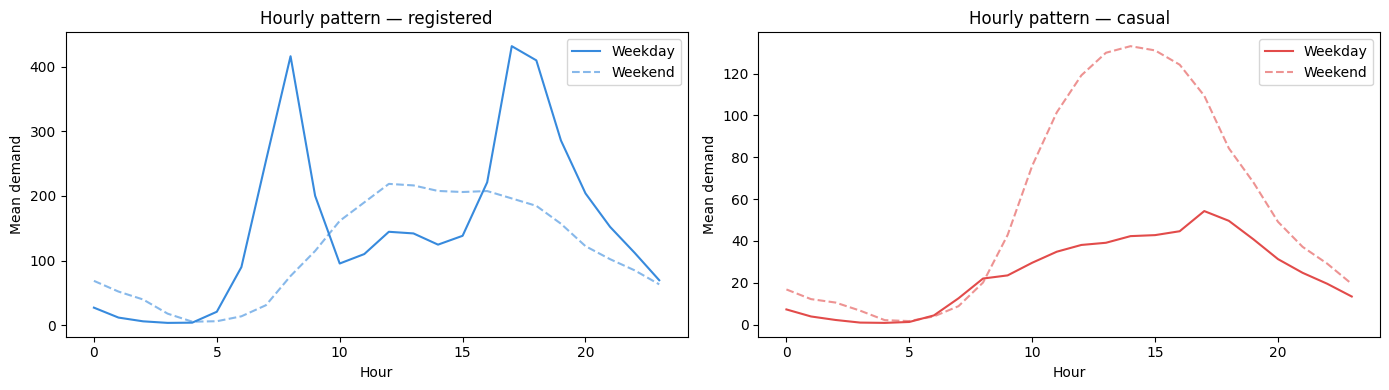

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col, color in zip(axes, ["registered", "casual"], ["#378ADD", "#E24B4A"]):
    weekday = train[train["workingday"] == 1].groupby("hr")[col].mean()
    weekend = train[train["workingday"] == 0].groupby("hr")[col].mean()
    ax.plot(weekday.index, weekday.values, label="Weekday", color=color)
    ax.plot(weekend.index, weekend.values, label="Weekend", color=color, linestyle="--", alpha=0.6)
    ax.set_title(f"Hourly pattern — {col}")
    ax.set_xlabel("Hour")
    ax.set_ylabel("Mean demand")
    ax.legend()

plt.tight_layout()
plt.show()

### 8.6 Full pipeline rebuild with all validated features

Now that all feature candidates have been evaluated, we rebuild the full pipeline from scratch with the final feature set. This is the clean, validated version that will be ported to `src/`.

In [88]:
# Add all new features to full df before splitting
df["is_rush_hour"] = (
    (df["hr"].between(7, 9) | df["hr"].between(17, 19)) &
    (df["workingday"] == 1)
).astype(int)

df["days_since_start"] = (df["dteday"] - df["dteday"].min()).dt.days

# cnt_lag_48 and cnt_lag_72 already added in section 8.4

# Rebuild split
train = df[df["dteday"] <= cutoff].copy()
val   = df[df["dteday"] >  cutoff].copy()

train = build_calendar_features(train)
val   = build_calendar_features(val)

# Targets
train["log_cnt"]        = np.log1p(train["cnt"])
train["log_registered"] = np.log1p(train["registered"])
train["log_casual"]     = np.log1p(train["casual"])

val["log_cnt"]        = np.log1p(val["cnt"])
val["log_registered"] = np.log1p(val["registered"])
val["log_casual"]     = np.log1p(val["casual"])

train = train.dropna()

print(f"Train: {len(train):,} rows | Val: {len(val):,} rows")
print(f"New features added: is_rush_hour, days_since_start, cnt_lag_48, cnt_lag_72")

Train: 13,747 rows | Val: 3,464 rows
New features added: is_rush_hour, days_since_start, cnt_lag_48, cnt_lag_72


In [89]:
FEATURES_V2 = [
    # Calendar
    "hr_sin", "hr_cos",
    "hr_workday", "hr_weekend", "hr_x_season",
    # New
    "is_rush_hour", "days_since_start",
    # Context
    "temp", "hum", "weathersit",
    # Lags
    "cnt_lag_1", "cnt_lag_2", "cnt_lag_3",
    "cnt_lag_8", "cnt_lag_24", "cnt_lag_48", "cnt_lag_72", "cnt_lag_168",
    "cnt_rolling_mean_24", "cnt_rolling_mean_168",
]

X_train_v2 = train[FEATURES_V2]
X_val_v2   = val[FEATURES_V2]

# Model 1: registered users
rf_registered = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_registered.fit(X_train_v2, train["log_registered"])

# Model 2: casual users
rf_casual = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_casual.fit(X_train_v2, train["log_casual"])

# Combined prediction
pred_registered = np.expm1(rf_registered.predict(X_val_v2))
pred_casual     = np.expm1(rf_casual.predict(X_val_v2))
pred_combined   = pred_registered + pred_casual

evaluate(val["cnt"], pred_combined, "RF v2 — split models + new features")
evaluate(val["cnt"], pred_log,      "RF v1 — original (cnt directo)")

RF v2 — split models + new features
  RMSE:  51.42
  RMSLE: 0.2573
  R²:    0.9455

RF v1 — original (cnt directo)
  RMSE:  53.63
  RMSLE: 0.2612
  R²:    0.9407



**Interpretation:** Any improvement in RMSE and RMSLE here validates both the new features and the split-model strategy. This is still a Random Forest with no tuning — the gains will compound further when we apply LightGBM with Optuna in `src/`.

## 9. Key Takeaways & Final Feature Set

### Feature candidates — results summary

| Feature | MI score | Decision | Reason |
|---|---|---|---|
| `is_rush_hour` | 0.13 | ✅ Keep | Incremental signal on top of hr_workday; explicit regime flag |
| `days_since_start` | 0.15 | ✅ Keep | Replaces `yr` (MI 0.04) with continuous growth trend |
| `apparent_temp` | 0.148 | ❌ Drop | Identical MI to `temp`; hum already in feature set |
| `cnt_lag_48` | 0.44 | ✅ Keep | Substantial signal; 2-day same-hour pattern |
| `cnt_lag_72` | 0.38 | ✅ Keep | Substantial signal; 3-day same-hour pattern |
| `yr` | 0.04 | ❌ Drop | Replaced by `days_since_start` |
| `cnt_lag_9`, `cnt_lag_10` | ~0.13 | ❌ Drop | Redundant with `cnt_lag_8` |
| `workingday`, `holiday` | ~0.01 | ❌ Drop | Subsumed by `hr_workday` / `hr_weekend` |
| `season`, `mnth_sin/cos` | ~0.04 | ❌ Drop | Subsumed by `hr_x_season` |
| `windspeed` | ~0.01 | ❌ Drop | Near-zero MI |

### Modelling strategy
- Train **two separate models**: one for `log(registered+1)`, one for `log(casual+1)`.
- Final prediction: `cnt = expm1(pred_registered) + expm1(pred_casual)`.
- Use **LightGBM with Optuna** (50 trials) as the production model.
- Evaluate on **RMSLE** as the primary metric (Kaggle official).
- Use **temporal train/val split** — never random.

### Final feature set
```
hr_sin, hr_cos, hr_workday, hr_weekend, hr_x_season,
is_rush_hour, days_since_start,
temp, hum, weathersit,
cnt_lag_1, cnt_lag_2, cnt_lag_3, cnt_lag_8,
cnt_lag_24, cnt_lag_48, cnt_lag_72, cnt_lag_168,
cnt_rolling_mean_24, cnt_rolling_mean_168
```